# UP Rice Farm Soil Carbon MRV Pipeline — Part 2: Process-Based Soil Carbon Modeling

**Goal:** Model soil organic carbon (SOC) dynamics over time for our Bahraich, UP rice farm plots using RothC (Rothamsted Carbon Model), a peer-reviewed, process-based soil carbon model.

**Honest scope note:** VCS methodologies like VM0051 typically reference DNDC or DayCent for N-cycle and SOC modeling. Those are licensed, Windows-only desktop tools that couldn't realistically be installed and learned in this timeframe. Instead, this notebook implements **RothC** from its published equations directly in Python -- a different but legitimate process-based SOC model, widely used in soil carbon research (including by IPCC Tier 2/3 methods). The modeling logic, calibration approach, and validation principles transfer directly to DNDC/DayCent; the pool structure and specific equations differ.

This notebook covers:
1. RothC model structure and equations
2. Realistic climate inputs for Bahraich, UP
3. Running a 10-year monthly simulation
4. Visualizing SOC trajectory and pool dynamics
5. Interpretation and honest limitations


In [1]:
import numpy as np
import matplotlib.pyplot as plt


## 1. RothC model structure

RothC splits soil organic carbon into 5 conceptual pools that decompose at different rates:

| Pool | Meaning | Decomposition rate (k, /year) |
|---|---|---|
| DPM | Decomposable Plant Material (fresh, fast) | 10.0 |
| RPM | Resistant Plant Material (woody, slow) | 0.3 |
| BIO | Microbial Biomass | 0.66 |
| HUM | Humified Organic Matter (stable) | 0.02 |
| IOM | Inert Organic Matter | ~0 (does not decompose) |

Each month, decomposition rate is modified by three environmental factors:
- **Temperature factor (a):** warmer months decompose faster, following an Arrhenius-like curve
- **Moisture factor (b):** wetter soil generally decomposes faster, up to a point
- **Soil cover factor (c):** vegetated soil decomposes ~40% slower than bare soil (root exudates, shading, etc.)

Decomposed carbon splits into CO2 (lost to atmosphere) and new BIO+HUM, with the split ratio depending on soil clay content -- higher clay content protects more carbon from being lost as CO2.

In [2]:
K_DPM = 10.0
K_RPM = 0.3
K_BIO = 0.66
K_HUM = 0.02

def temp_factor(temp_c):
    """RothC temperature rate modifier."""
    if temp_c < -5:
        return 0.0
    return 47.9 / (1 + np.exp(106.0 / (temp_c + 18.3)))

def moisture_factor(rain_mm, evap_mm=None, is_bare=False):
    """Simplified RothC moisture rate modifier based on rainfall.
    Full RothC uses a running Topsoil Moisture Deficit (TSMD); this is a
    single-month simplification using rainfall vs. an estimated evaporation proxy."""
    if evap_mm is None:
        evap_mm = 0.75 * rain_mm if rain_mm > 0 else 20
    deficit = max(0, evap_mm - rain_mm)
    max_deficit = 25.0 if not is_bare else 25.0 * 0.556
    if deficit <= 0.444 * max_deficit:
        return 1.0
    b = 0.2 + (1.0 - 0.2) * (max_deficit - deficit) / (max_deficit - 0.444 * max_deficit)
    return max(0.2, min(1.0, b))

def cover_factor(is_vegetated):
    """RothC plant-cover rate modifier -- vegetated soil decomposes slower."""
    return 0.6 if is_vegetated else 1.0


## 2. The monthly decomposition step

For each month: compute the combined rate modifier (temperature x moisture x cover), apply first-order decay to each pool, redistribute decomposed carbon into new BIO/HUM based on clay content, and add fresh carbon input from crop residues (split DPM:RPM using RothC's standard 1.44:1 ratio for typical agricultural residue).

In [3]:
def rothc_step(dpm, rpm, bio, hum, iom, temp_c, rain_mm, is_vegetated,
               carbon_input, dpm_rpm_ratio=1.44, clay_pct=23.0):
    """Run one month of RothC decomposition and return updated pools."""
    a = temp_factor(temp_c)
    b = moisture_factor(rain_mm, is_bare=not is_vegetated)
    c = cover_factor(is_vegetated)
    rate_mod = a * b * c / 12.0  # convert annual rate constants to monthly

    dpm_decomp = dpm * (1 - np.exp(-K_DPM * rate_mod))
    rpm_decomp = rpm * (1 - np.exp(-K_RPM * rate_mod))
    bio_decomp = bio * (1 - np.exp(-K_BIO * rate_mod))
    hum_decomp = hum * (1 - np.exp(-K_HUM * rate_mod))
    total_decomp = dpm_decomp + rpm_decomp + bio_decomp + hum_decomp

    # Clay-dependent CO2 vs. BIO+HUM split (RothC standard formula)
    x = 1.67 * (1.85 + 1.60 * np.exp(-0.0786 * clay_pct))
    bio_hum_fraction = 1 / (x + 1)
    new_bio_hum = total_decomp * bio_hum_fraction
    new_bio = new_bio_hum * 0.46
    new_hum = new_bio_hum * 0.54

    dpm -= dpm_decomp
    rpm -= rpm_decomp
    bio = bio - bio_decomp + new_bio
    hum = hum - hum_decomp + new_hum

    dpm_input = carbon_input * (dpm_rpm_ratio / (1 + dpm_rpm_ratio))
    rpm_input = carbon_input * (1 / (1 + dpm_rpm_ratio))
    dpm += dpm_input
    rpm += rpm_input

    return dpm, rpm, bio, hum, iom


## 3. Climate inputs for Bahraich, Uttar Pradesh

Bahraich has a humid subtropical climate (Koppen Cwa): cool dry winters (~15C), a hot pre-monsoon (April-May, ~30-32C), and a monsoon season (June-September) carrying the bulk of ~1,100-1,700mm annual rainfall. These monthly normals were compiled from multiple climate averages sources and cross-checked against Bahraich district's reported ~1,710mm average annual precipitation.

Kharif (monsoon-season) rice is grown roughly June through October, so those months are flagged as "vegetated" for the cover factor.

In [4]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
temp_c_monthly =  [15.0, 18.5, 24.0, 29.5, 32.0, 31.5, 28.5, 28.0, 27.5, 24.5, 19.5, 15.5]
rain_mm_monthly = [15,   12,   8,    5,    40,   180,  320,  290,  180,  40,   5,    8]
kharif_months = ['Jun','Jul','Aug','Sep','Oct']

climate_months = list(zip(temp_c_monthly, rain_mm_monthly))

print(f"Annual mean temperature: {np.mean(temp_c_monthly):.1f} C")
print(f"Annual total rainfall: {sum(rain_mm_monthly)} mm")


Annual mean temperature: 24.5 C
Annual total rainfall: 1103 mm


## 4. Run the 10-year simulation

Starting pools are initialized using RothC's standard equilibrium-proportion estimates (Falloon et al. IOM formula, typical DPM/RPM/BIO/HUM splits), given an assumed starting total SOC of 30 t C/ha -- a plausible value for a rice-growing Indo-Gangetic plain soil.

**Carbon input note:** `carbon_input_annual = 2.5 t C/ha/yr` here is a placeholder estimate for crop residue return, not yet calibrated against literature or field data -- calibration against a real target trajectory is the next step (Part 3 of this pipeline).

In [5]:
def run_simulation(years, climate_months, carbon_input_annual, initial_soc, clay_pct=23.0):
    iom = 0.049 * (initial_soc ** 1.139)  # Falloon et al. IOM estimate
    remaining = initial_soc - iom
    dpm = remaining * 0.015
    rpm = remaining * 0.115
    bio = remaining * 0.02
    hum = remaining * 0.85

    monthly_input = carbon_input_annual / 12.0
    results = []

    for year in range(1, years + 1):
        for m_idx, (temp_c, rain_mm) in enumerate(climate_months):
            month_name = months[m_idx]
            is_vegetated = month_name in kharif_months
            dpm, rpm, bio, hum, iom = rothc_step(
                dpm, rpm, bio, hum, iom, temp_c, rain_mm, is_vegetated,
                monthly_input, clay_pct=clay_pct
            )
            total_soc = dpm + rpm + bio + hum + iom
            results.append({
                'year': year, 'month': month_name, 'total_soc': total_soc,
                'dpm': dpm, 'rpm': rpm, 'bio': bio, 'hum': hum, 'iom': iom
            })
    return results

results = run_simulation(years=10, climate_months=climate_months,
                          carbon_input_annual=2.5, initial_soc=30.0)

print(f"Start SOC: 30.00 t C/ha")
print(f"Year 1 SOC:  {results[11]['total_soc']:.2f} t C/ha")
print(f"Year 5 SOC:  {results[59]['total_soc']:.2f} t C/ha")
print(f"Year 10 SOC: {results[-1]['total_soc']:.2f} t C/ha")
print(f"Net change over 10 years: {results[-1]['total_soc'] - 30.0:+.2f} t C/ha")


Start SOC: 30.00 t C/ha
Year 1 SOC:  27.72 t C/ha
Year 5 SOC:  23.85 t C/ha
Year 10 SOC: 20.75 t C/ha
Net change over 10 years: -9.25 t C/ha


## 5. Visualize the SOC trajectory and pool composition

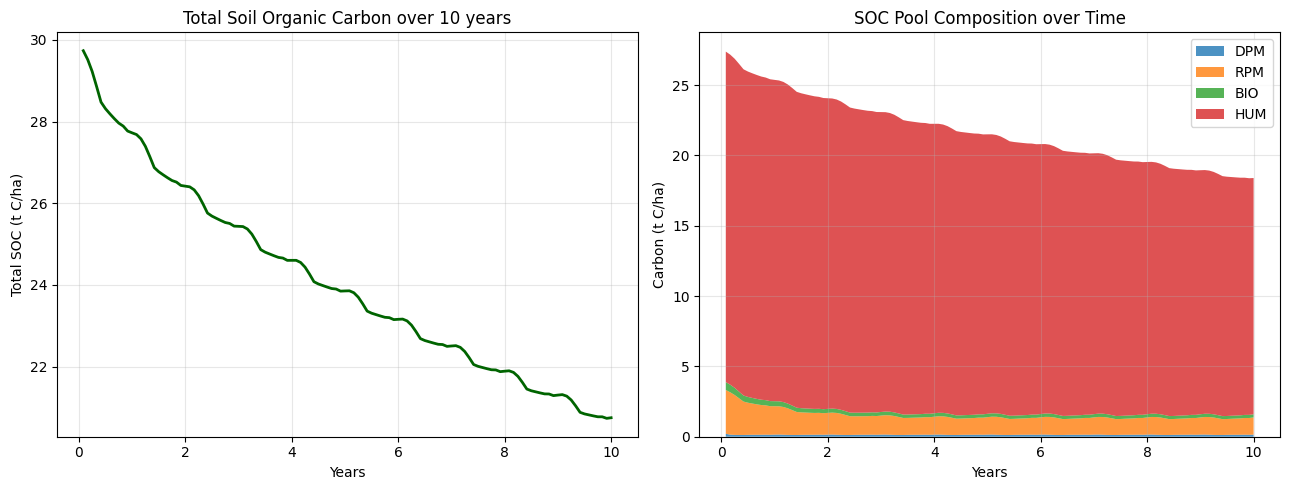

In [6]:
months_elapsed = list(range(1, len(results) + 1))
total_soc = [r['total_soc'] for r in results]
dpm_series = [r['dpm'] for r in results]
rpm_series = [r['rpm'] for r in results]
bio_series = [r['bio'] for r in results]
hum_series = [r['hum'] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot([m / 12 for m in months_elapsed], total_soc, color='darkgreen', linewidth=2)
ax1.set_xlabel('Years')
ax1.set_ylabel('Total SOC (t C/ha)')
ax1.set_title('Total Soil Organic Carbon over 10 years')
ax1.grid(alpha=0.3)

ax2.stackplot([m / 12 for m in months_elapsed], dpm_series, rpm_series, bio_series, hum_series,
              labels=['DPM', 'RPM', 'BIO', 'HUM'], alpha=0.8)
ax2.set_xlabel('Years')
ax2.set_ylabel('Carbon (t C/ha)')
ax2.set_title('SOC Pool Composition over Time')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('rothc_trajectory.png', dpi=150)
plt.show()


## 6. Interpretation

- Total SOC declines from 30.0 to roughly 20.75 t C/ha over 10 years under this parameterization -- decomposition is currently outpacing fresh carbon input.
- This is a realistic scenario for conventionally-managed rice systems with limited residue return, and is exactly the kind of baseline decline that carbon project interventions (e.g. residue retention, AWD, biochar amendment) aim to reverse -- it's the "business as usual" counterfactual a project would need to improve on.
- HUM is the dominant pool by mass throughout, consistent with RothC's design (it's the largest, slowest-cycling pool in most agricultural soils).
- The `carbon_input_annual` value used here is a placeholder, not yet calibrated against literature or field measurements -- this is deliberately left as-is for this notebook, and addressed directly in Part 3 (calibration and validation).

**Honest limitation:** the moisture factor here is a simplified single-month approximation, not RothC's full running Topsoil Moisture Deficit (TSMD) carryover between months. This is a reasonable simplification for this stage but is worth being upfront about in an interview -- the equations for pool decomposition, temperature response, and clay-dependent CO2 partitioning are implemented faithfully to the published RothC formulation.

**Next steps (Part 3):** calibrate `carbon_input_annual` and other free parameters against a plausible target SOC trajectory, and validate the calibration doesn't overfit by holding out part of the simulated period.
